In [1]:
import pandas as pd
import sqlite3

In [2]:
db_file = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_file)

1. Run a query that gets the datetime from the pageviews table, selecting only users and not admins.

In [9]:
query = """
SELECT datetime FROM pageviews WHERE uid LIKE 'user_%' LIMIT 10
"""

pd.read_sql(query, conn)

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
5,2020-04-18 12:06:13.237290
6,2020-04-18 12:06:35.574114
7,2020-04-18 12:19:50.182714
8,2020-04-18 18:14:53.813657
9,2020-04-18 18:20:05.419381


2. Using Pandas, create a new dataframe where the visits are counted and grouped by date.

In [20]:
query = """
SELECT DATE(datetime) AS date, COUNT(datetime) AS views
FROM pageviews 
WHERE uid LIKE 'user_%' 
GROUP BY DATE(datetime)
"""
visits_df = pd.read_sql(query, conn)
print(visits_df)

          date  views
0   2020-04-17      1
1   2020-04-18     23
2   2020-04-19     15
3   2020-04-21      3
4   2020-04-22      1
5   2020-04-23      5
6   2020-04-25      1
7   2020-04-26      8
8   2020-04-28      2
9   2020-04-29      4
10  2020-04-30      9
11  2020-05-01      3
12  2020-05-02      6
13  2020-05-03     19
14  2020-05-04      1
15  2020-05-05      1
16  2020-05-06      3
17  2020-05-07      2
18  2020-05-08     48
19  2020-05-09     19
20  2020-05-10    110
21  2020-05-11    200
22  2020-05-12     85
23  2020-05-13    102
24  2020-05-14    187
25  2020-05-15     29
26  2020-05-16      4
27  2020-05-17      9
28  2020-05-18     51
29  2020-05-19     11
30  2020-05-20     12
31  2020-05-21     11
32  2020-05-22      2


3. Using the Pandas method .plot(), create a graph:
- The size of the font should be 8.
- The size of the figure is (15, 8).
- The graph must have the title "Views per Day".
- Notice the rotation of the xticks on the graph below.

<Axes: title={'center': 'Views per Day'}, xlabel='date'>

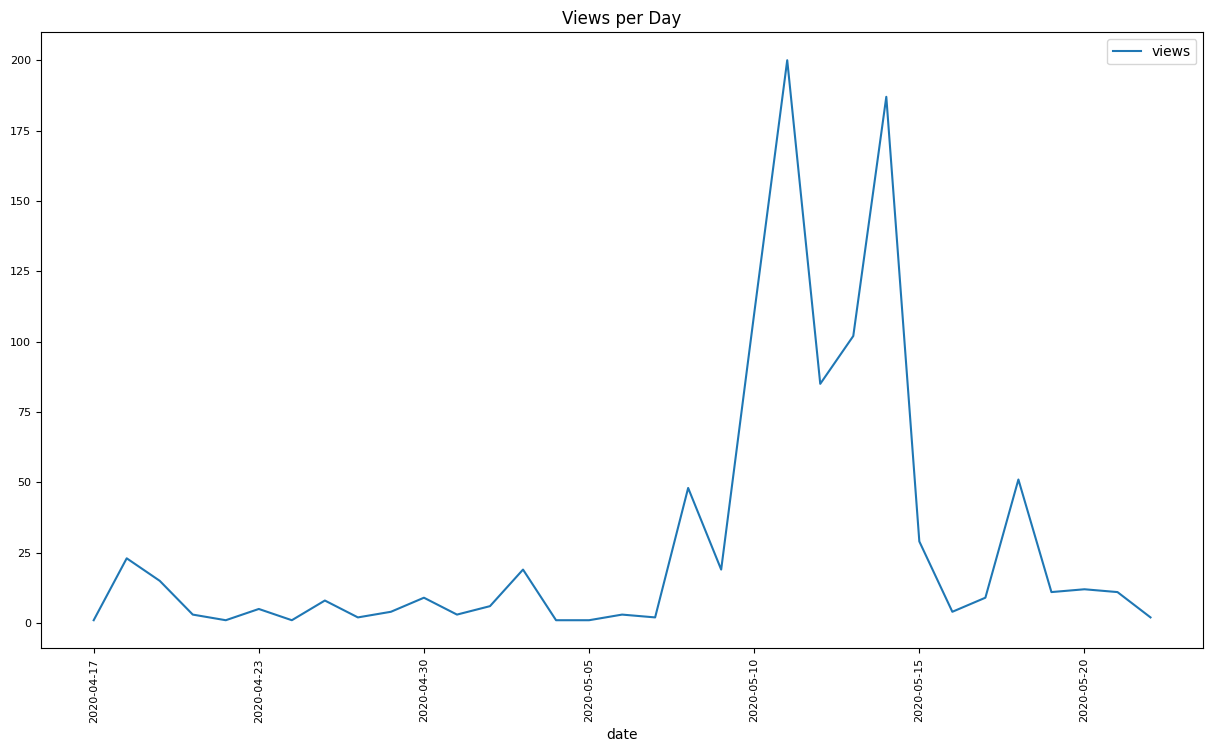

In [22]:
visits_df.plot(
    fontsize=8,
    figsize=(15, 8),
    title="Views per Day",
    x='date',
    y='views',
    rot=90
)

3. Close the connection to the database.

In [23]:
conn.close()